In [1]:
import os
import gc
import torch

from typing import Tuple
from arcgis.learn import prepare_data, UnetClassifier
from fastai.vision.transform import brightness, contrast, crop, rand_zoom, rotate, skew

### Check if cuda is enabled

In [2]:
torch.cuda.is_available()

True

### Clear the cuda cache

In [3]:
torch.cuda.empty_cache()
gc.collect()

0

### Read the data

In [4]:
data_path = os.path.join("C:", os.sep, "Data", "Tanks256")
chip_size = 224
batch_size = 16

ranges = (0, 1)
transform_train = [
    crop(size=chip_size, p=1.0, row_pct=ranges, col_pct=ranges),
    brightness(change=(0.4, 0.6)),
    contrast(scale=(0.75, 1.5)),
    rand_zoom(scale=(0.90, 1.10)),
]

# Create validation transformation.
transform_valid = [crop(size=chip_size, p=1.0, row_pct=0.5, col_pct=0.5)]
transforms = (transform_train, transform_valid)

data = prepare_data(data_path, chip_size=chip_size, batch_size=batch_size, transforms=transforms)

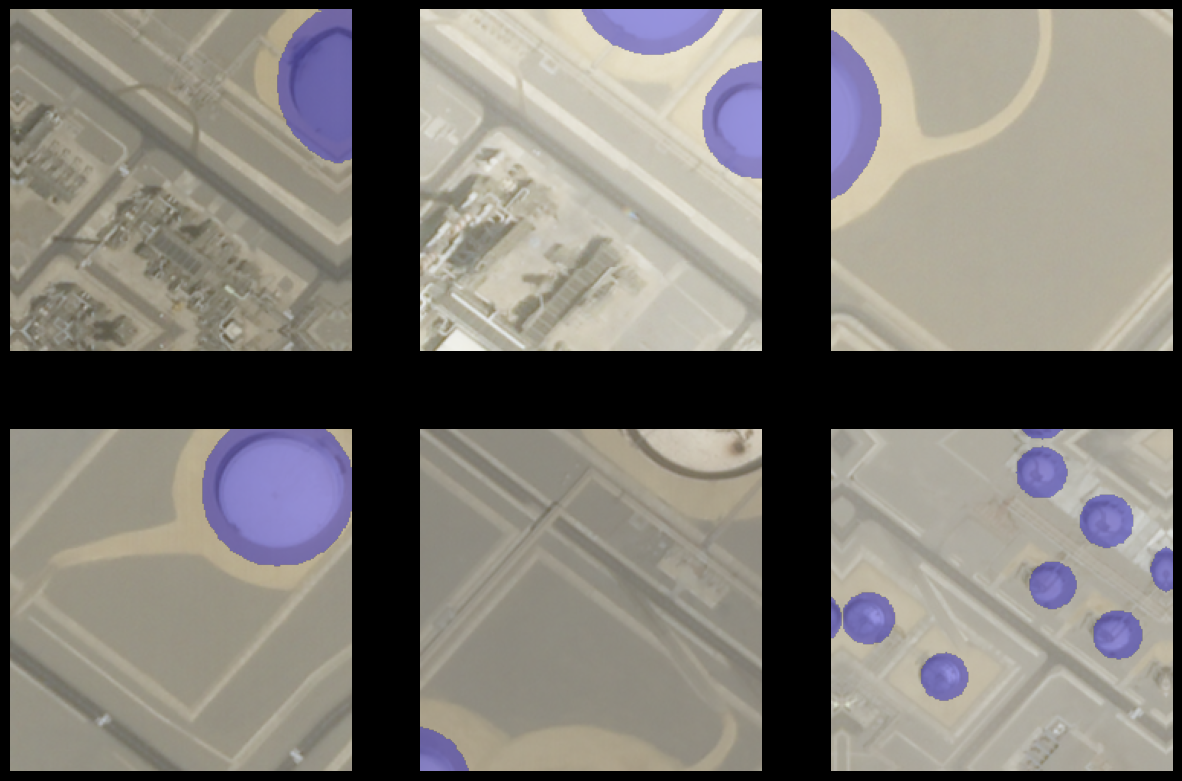

In [5]:
data.show_batch(rows=2)

In [6]:
unet = UnetClassifier(data)

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to C:\Users\mraad/.cache\torch\hub\checkpoints\resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s] ﻿


In [7]:
# unet.lr_find()

In [8]:
unet.fit(epochs=5, lr=1e-4, early_stopping=True)

epoch     train_loss  valid_loss  accuracy  dice      time    
0         0.346151    0.082021    0.969014  0.858899  02:19     
1         0.090841    0.041903    0.983322  0.915043  01:59     
2         0.045294    0.053730    0.977858  0.913872  02:00     
3         0.035112    0.028270    0.988920  0.948823  01:59     
4         0.029281    0.024967    0.990214  0.948539  02:00     


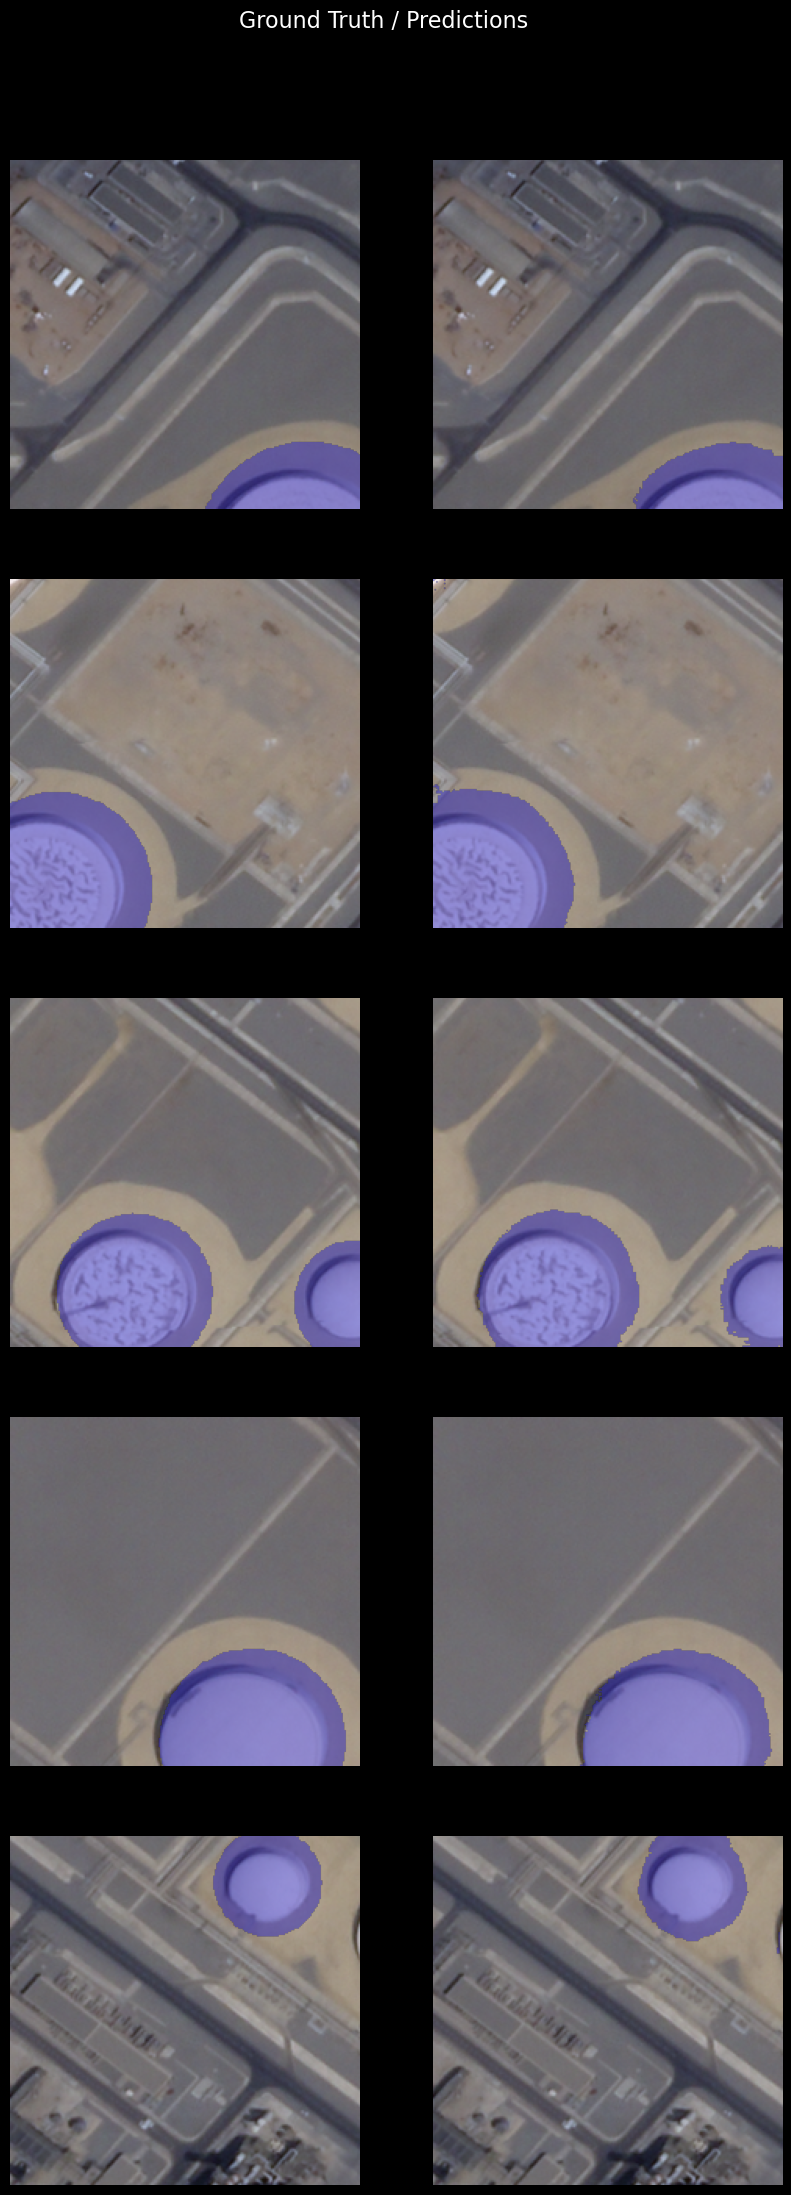

In [9]:
unet.show_results()

In [10]:
dir(unet)

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_arcgis_init_callback', '_available_metrics', '_backbone', '_backend', '_check_backbone_support', '_check_data_support_with_pretrained_path', '_check_dataset_support', '_check_requisites', '_check_tf', '_code', '_create_emd_template', '_create_html', '_create_tfonnx_emd_template', '_data', '_device', '_final_class_weight', '_find_lr', '_fit_callbacks', '_framework', '_get_emd_params', '_get_model_metrics', '_get_post_processed_model', '_get_tfonnx_emd_params', '_ignore_classes', '_ignore_mapped_class', '_init_tensorflow', '_intialize_tensorflow', '_is_checkpointed', '_is_multispectral', '_learning_rate', '_loss_function_tf', '_model_metrics', '_m

In [11]:
unet.per_class_metrics()

,NoData,Tank
precision,0.995382,0.962782
recall,0.993005,0.975171
f1,0.994192,0.968937


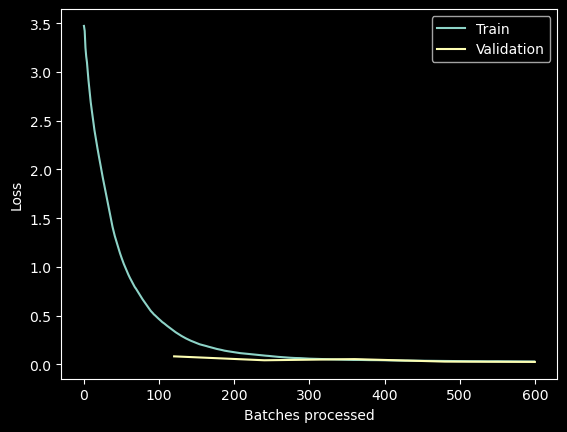

In [12]:
unet.plot_losses()

In [13]:
unet.save("unet_resnet34")

Computing model metrics...


WindowsPath('C:/Data/Tanks256/models/unet_resnet34')